<a href="https://colab.research.google.com/github/DustinChapin/analisis-siniestros-ecuador/blob/main/ProyectoBI.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

### 🚗 PROYECTO: Análisis de Siniestros de Tránsito en Ecuador

### Séptimo Semestre BI

Link de datos: https://www.ecuadorencifras.gob.ec/transporte/

### Minería de Datos y Machine Learning


**Hecho por:**
* Dustin Chapin

---
### 📌 Descripción del Proyecto
Este cuaderno de Google Colab contiene el desarrollo metodológico para el preprocesamiento de la base de datos oficial de siniestros viales. El objetivo es estructurar y transformar la información cruda mediante limpieza, imputación y análisis estadístico exploratorio (EDA).

Estos pasos garantizan la calidad de los datos para su posterior ingesta en algoritmos predictivos de aprendizaje supervisado.

# 1. Importación de Librerías y Carga de Datos

In [ ]:
# Importar librerías básicas
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import os
import warnings
warnings.filterwarnings("ignore")

# Conectar Google Colab con Google Drive
from google.colab import drive
drive.mount("/content/drive")

Mounted at /content/drive


## 1.1 Definición de Rutas y Lectura de Archivos

In [ ]:
path = "/content/drive/MyDrive/Proyecto_BI_Septimo_Semestre"

# Nombre EXACTO del archivo del INEC que vimos en tu computadora
archivo = "/content/drive/MyDrive/Proyecto_BI_Septimo_Semestre/2024_BDD_SINIESTROS_TRÁNSITO.csv"
ruta_archivo = archivo # Corregido para evitar duplicidad en la ruta

# Verificación de seguridad antes de leer el archivo
if os.path.exists(ruta_archivo):
    print("✅ ¡Archivo encontrado con éxito en tu Drive!")

    # Cargar el dataset en un DataFrame
    df_data = pd.read_csv(ruta_archivo, sep=';', encoding='utf-8')

    print(f"✅ Datos cargados correctamente. El dataset tiene {df_data.shape[0]} filas y {df_data.shape[1]} columnas.")

    # Mostrar las primeras 3 filas para confirmar visualmente
    display(df_data.head(3))
else:
    print("❌ ERROR: No se encontró el archivo.")
    print(f"Verifica que la ruta sea correcta: {ruta_archivo}")

✅ ¡Archivo encontrado con éxito en tu Drive!
✅ Datos cargados correctamente. El dataset tiene 21220 filas y 11 columnas.


,PROVINCIA,CANTÓN,MES,DIA,HORA,ZONA,NUM_FALLECIDO,NUM_LESIONADO,TOTAL_VICTIMAS,CLASE,CAUSA
0,9,901,1,1,2,1,0,0,0,4,4
1,9,901,1,1,3,1,0,1,1,3,4
2,9,901,1,1,4,1,0,1,1,7,1


# 2. Recodificación y Limpieza de Variables

In [ ]:
# 1. Crear un diccionario con los códigos oficiales de provincias del Ecuador
diccionario_provincias = {
    1: 'Azuay', 2: 'Bolívar', 3: 'Cañar', 4: 'Carchi', 5: 'Cotopaxi',
    6: 'Chimborazo', 7: 'El Oro', 8: 'Esmeraldas', 9: 'Guayas', 10: 'Imbabura',
    11: 'Loja', 12: 'Los Ríos', 13: 'Manabí', 14: 'Morona Santiago', 15: 'Napo',
    16: 'Pastaza', 17: 'Pichincha', 18: 'Tungurahua', 19: 'Zamora Chinchipe',
    20: 'Galápagos', 21: 'Sucumbíos', 22: 'Orellana', 23: 'Santo Domingo de los Tsáchilas',
    24: 'Santa Elena'
}

# 2. Crear un diccionario para las zonas (Generalmente 1 es Urbana y 2 es Rural en el INEC)
diccionario_zonas = {
    1: 'Urbana',
    2: 'Rural'
}

# 3. Aplicar la recodificación creando nuevas columnas o reemplazando las existentes
df_data['PROVINCIA_TEXTO'] = df_data['PROVINCIA'].map(diccionario_provincias)
df_data['ZONA_TEXTO'] = df_data['ZONA'].map(diccionario_zonas)

# Mostrar el resultado para verificar que funcionó
display(df_data[['PROVINCIA', 'PROVINCIA_TEXTO', 'ZONA', 'ZONA_TEXTO']].head())

,PROVINCIA,PROVINCIA_TEXTO,ZONA,ZONA_TEXTO
0,9,Guayas,1,Urbana
1,9,Guayas,1,Urbana
2,9,Guayas,1,Urbana
3,9,Guayas,1,Urbana
4,9,Guayas,1,Urbana


# 3. Exploración General del Dataset (EDA)

In [ ]:
# Obtener el tamaño del dataset (filas y columnas)
print("Tamaño del dataset:", df_data.shape)

# Mostrar información general (tipos de datos y valores no nulos)
print("\n--- Información general del dataset ---")
df_data.info()

# Identificar variables numéricas y categóricas automáticamente[cite: 1]
variables_numericas = df_data.select_dtypes(include=["int64", "float64"]).columns.tolist()
variables_categoricas = df_data.select_dtypes(include=["object", "category"]).columns.tolist()

print("\n--- Clasificación de Variables ---")
print("Variables Numéricas detectadas:", variables_numericas)
print("Variables Categóricas detectadas:", variables_categoricas)

Tamaño del dataset: (21220, 13)

--- Información general del dataset ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21220 entries, 0 to 21219
Data columns (total 13 columns):
 #   Column           Non-Null Count  Dtype 
---  ------           --------------  ----- 
 0   PROVINCIA        21220 non-null  int64 
 1   CANTÓN           21220 non-null  int64 
 2   MES              21220 non-null  int64 
 3   DIA              21220 non-null  int64 
 4   HORA             21220 non-null  int64 
 5   ZONA             21220 non-null  int64 
 6   NUM_FALLECIDO    21220 non-null  int64 
 7   NUM_LESIONADO    21220 non-null  int64 
 8   TOTAL_VICTIMAS   21220 non-null  int64 
 9   CLASE            21220 non-null  int64 
 10  CAUSA            21220 non-null  int64 
 11  PROVINCIA_TEXTO  21220 non-null  object
 12  ZONA_TEXTO       21220 non-null  object
dtypes: int64(11), object(2)
memory usage: 2.1+ MB

--- Clasificación de Variables ---
Variables Numéricas detectadas: ['PROVINCIA', 'CANTÓN', 

## 3.1 Estadísticos Básicos y Frecuencias

In [ ]:
# Seleccionamos una variable numérica clave para el análisis
var_analisis = "TOTAL_VICTIMAS"

print(f"--- Estadísticos descriptivos de: {var_analisis} ---")

# Cálculo de media, mediana, moda, varianza y desviación estándar
print("Media:", df_data[var_analisis].mean())
print("Mediana:", df_data[var_analisis].median())
print("Moda:", df_data[var_analisis].mode()[0])
print("Varianza:", df_data[var_analisis].var())
print("Desviación estándar:", df_data[var_analisis].std())

# Coeficiente de variación (Desviación estándar / Media)
coef_variacion = df_data[var_analisis].std() / df_data[var_analisis].mean()
print("Coeficiente de variación:", coef_variacion)

print("\n--- Cuartiles (25%, 50%, 75%) ---")
print(df_data[var_analisis].quantile([0.25, 0.50, 0.75]))

print("\n--- Percentiles (5%, 25%, 50%, 75%, 95%) ---")
print(df_data[var_analisis].quantile([0.05, 0.25, 0.50, 0.75, 0.95]))

--- Estadísticos descriptivos de: TOTAL_VICTIMAS ---
Media: 0.9714420358152687
Mediana: 1.0
Moda: 1
Varianza: 1.3208300991425073
Desviación estándar: 1.1492737268129414
Coeficiente de variación: 1.1830594975730384

--- Cuartiles (25%, 50%, 75%) ---
0.25    0.0
0.50    1.0
0.75    1.0
Name: TOTAL_VICTIMAS, dtype: float64

--- Percentiles (5%, 25%, 50%, 75%, 95%) ---
0.05    0.0
0.25    0.0
0.50    1.0
0.75    1.0
0.95    3.0
Name: TOTAL_VICTIMAS, dtype: float64


## 3.2 Tablas de Frecuencias y Resúmenes

In [ ]:
print("--- Tabla de Frecuencias: Accidentes por Zona ---")
# Frecuencias absolutas de variables categóricas
print(df_data["ZONA_TEXTO"].value_counts())

print("\n--- Tabla de Frecuencias: Top 5 Provincias con más accidentes ---")
print(df_data["PROVINCIA_TEXTO"].value_counts().head(5))

print("\n--- Resúmenes Agrupados ---")
# Promedio de víctimas agrupado por zona
print("\nPromedio de víctimas por Zona:")
print(df_data.groupby("ZONA_TEXTO")["TOTAL_VICTIMAS"].mean())

# Promedio de víctimas agrupado por Provincia (Top 5)
print("\nPromedio de víctimas por Provincia:")
promedio_provincia = df_data.groupby("PROVINCIA_TEXTO")["TOTAL_VICTIMAS"].mean().sort_values(ascending=False)
print(promedio_provincia.head(5))

--- Tabla de Frecuencias: Accidentes por Zona ---
ZONA_TEXTO
Urbana    14047
Rural      7173
Name: count, dtype: int64

--- Tabla de Frecuencias: Top 5 Provincias con más accidentes ---
PROVINCIA_TEXTO
Guayas        7253
Pichincha     4327
Azuay         1416
Manabí        1255
Tungurahua    1090
Name: count, dtype: int64

--- Resúmenes Agrupados ---

Promedio de víctimas por Zona:
ZONA_TEXTO
Rural     1.109438
Urbana    0.900975
Name: TOTAL_VICTIMAS, dtype: float64

Promedio de víctimas por Provincia:
PROVINCIA_TEXTO
Carchi     1.710526
Napo       1.566667
Pastaza    1.480000
Bolívar    1.360294
Cañar      1.338462
Name: TOTAL_VICTIMAS, dtype: float64


# 4. Transformación de Datos y Variable Objetivo

In [ ]:

# Si TOTAL_VICTIMAS es 0, es "Daños Materiales". Si es mayor a 0, es "Con Víctimas".
df_data["ESTADO_ACCIDENTE"] = np.where(
    df_data["TOTAL_VICTIMAS"] == 0,
    "Daños Materiales",
    "Con Víctimas"
)

# Convertir la variable objetivo a valores numéricos (0 y 1)[cite: 1]
df_data["TARGET"] = df_data["ESTADO_ACCIDENTE"].map({"Daños Materiales": 0, "Con Víctimas": 1})

print("--- Balance de clases de la variable objetivo ---")
print(df_data["ESTADO_ACCIDENTE"].value_counts())

# 4.2 Limpieza de Datos: Duplicados[cite: 1]
# Crear copia para limpieza[cite: 1]
df_limpio = df_data.copy()

duplicados = df_limpio.duplicated().sum()
print(f"\nSe encontraron {duplicados} registros duplicados.")

if duplicados > 0:
    df_limpio = df_limpio.drop_duplicates()
    print(f"Duplicados eliminados. Nuevo tamaño: {df_limpio.shape}")

# 4.3 Tratamiento de valores faltantes[cite: 1]
print("\n--- Porcentaje de valores faltantes por columna ---")
porcentaje_faltantes = (df_limpio.isnull().sum() / len(df_limpio)) * 100
print(porcentaje_faltantes[porcentaje_faltantes > 0])

# Eliminar columnas con más del 50% de faltantes (si existieran)[cite: 1]
columnas_eliminar = porcentaje_faltantes[porcentaje_faltantes > 50].index
df_limpio = df_limpio.drop(columns=columnas_eliminar)
print(f"\nColumnas después de eliminar las que tienen >50% de faltantes: {df_limpio.shape[1]}")

--- Balance de clases de la variable objetivo ---
ESTADO_ACCIDENTE
Con Víctimas        14013
Daños Materiales     7207
Name: count, dtype: int64

Se encontraron 443 registros duplicados.
Duplicados eliminados. Nuevo tamaño: (20777, 15)

--- Porcentaje de valores faltantes por columna ---
Series([], dtype: float64)

Columnas después de eliminar las que tienen >50% de faltantes: 15


# 5. Análisis Visual de Siniestralidad (General)

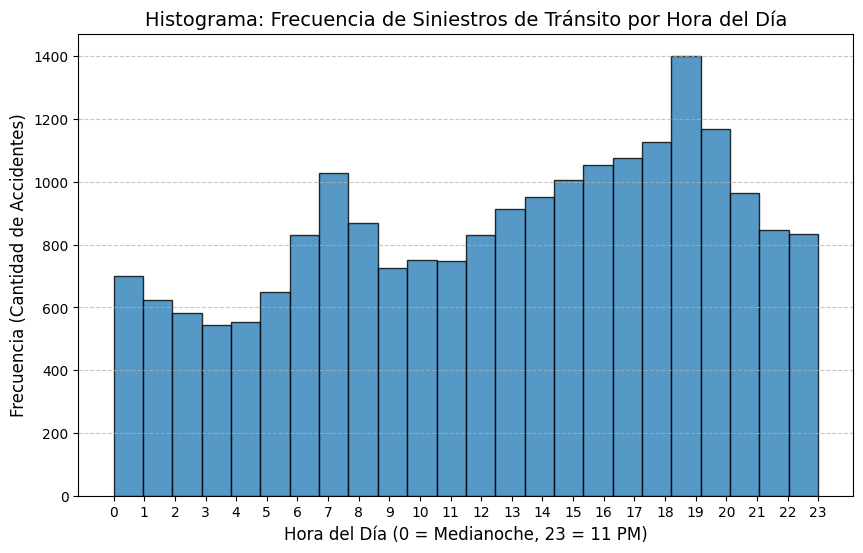

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar el tamaño del gráfico
plt.figure(figsize=(10, 6))

# Crear el histograma con la variable HORA (24 bins para las 24 horas del día)
plt.hist(df_limpio["HORA"].dropna(), bins=24, color='#2c7fb8', edgecolor='black', alpha=0.8)

# Añadir títulos y etiquetas
plt.title("Histograma: Frecuencia de Siniestros de Tránsito por Hora del Día", fontsize=14)
plt.xlabel("Hora del Día (0 = Medianoche, 23 = 11 PM)", fontsize=12)
plt.ylabel("Frecuencia (Cantidad de Accidentes)", fontsize=12)

# Asegurar que se muestren todas las horas en el eje X
plt.xticks(range(0, 24))

# Mostrar una cuadrícula de fondo para facilitar la lectura
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Mostrar el gráfico
plt.show()

## 5.1 Distribución Horaria de los Siniestros

## 5.2 Análisis de Dispersión y Outliers

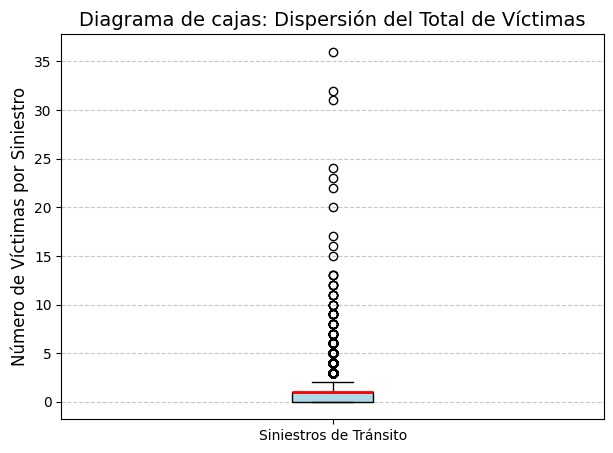

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 5))

# Crear el diagrama de cajas para la variable TOTAL_VICTIMAS
# Usamos patch_artist=True para darle un poco de color a la caja
plt.boxplot(df_limpio["TOTAL_VICTIMAS"].dropna(), vert=True, patch_artist=True,
            boxprops=dict(facecolor="lightblue", color="black"),
            medianprops=dict(color="red", linewidth=2))

# Añadir títulos y etiquetas
plt.title("Diagrama de cajas: Dispersión del Total de Víctimas", fontsize=14)
plt.ylabel("Número de Víctimas por Siniestro", fontsize=12)

# Quitar la etiqueta del eje X ya que solo es una variable
plt.xticks([1], ["Siniestros de Tránsito"])

# Mostrar el gráfico
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()

**Interpretación:** El diagrama de cajas permite observar la dispersión de la cantidad de víctimas (lesionados y fallecidos) generadas por cada siniestro de tránsito. La caja principal concentra a la gran mayoría de los accidentes, cuyos valores oscilan entre 0 y 1 víctima. Los puntos individuales ubicados por encima del "bigote" superior representan los posibles valores atípicos (outliers). En este contexto, estos valores anómalos son de sumo interés para el análisis, ya que representan accidentes graves de magnitud extraordinaria (por ejemplo, accidentes de transporte público o choques múltiples) que se escapan del comportamiento vial habitual.

## 5.3 Top 10 Provincias (Volumen Absoluto)

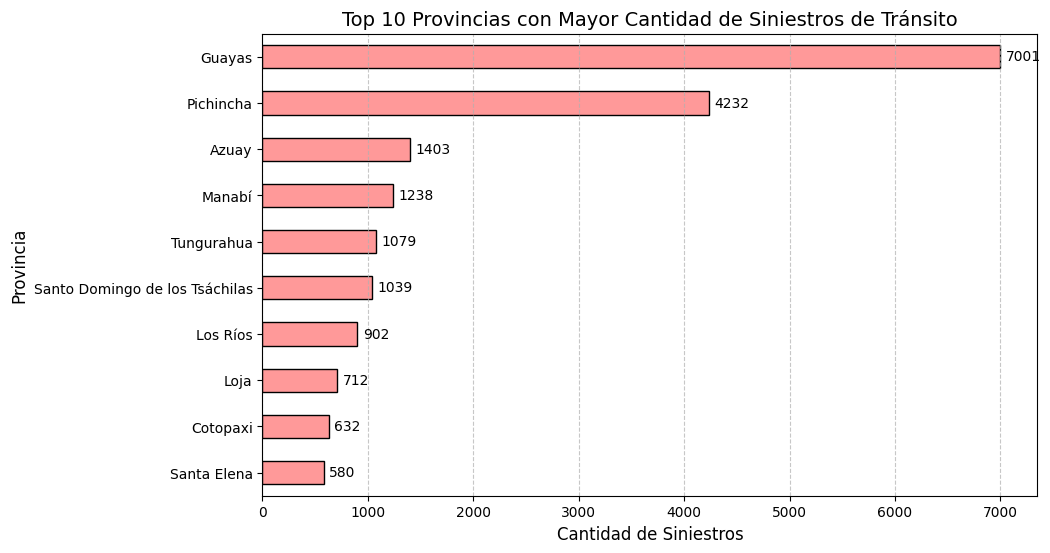

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# Obtener el Top 10 de provincias con más siniestros y ordenarlos de menor a mayor
# (para que el más alto quede en la parte superior del gráfico)
top_provincias = df_limpio["PROVINCIA_TEXTO"].value_counts().head(10).sort_values(ascending=True)

# Crear el gráfico de barras horizontales
top_provincias.plot(kind='barh', color='#ff9999', edgecolor='black')

# Añadir títulos y etiquetas
plt.title("Top 10 Provincias con Mayor Cantidad de Siniestros de Tránsito", fontsize=14)
plt.xlabel("Cantidad de Siniestros", fontsize=12)
plt.ylabel("Provincia", fontsize=12)

# Mostrar valores numéricos al final de cada barra para mayor precisión
for index, value in enumerate(top_provincias):
    plt.text(value + 50, index, str(value), va='center', fontsize=10)

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Interpretación:** El gráfico horizontal permite observar qué niveles geográficos tienen mayor presencia dentro del dataset. Esta variable es fundamental porque la ubicación (provincia) puede influir directamente en la cantidad y gravedad de los siniestros debido a factores como el parque automotor, el estado de las vías y la densidad poblacional. Identificar estas zonas de alta incidencia es el primer paso en la minería de datos para focalizar políticas de prevención vial.

**Distribución Porcentual de la Gravedad de los Siniestros de Tránsito**

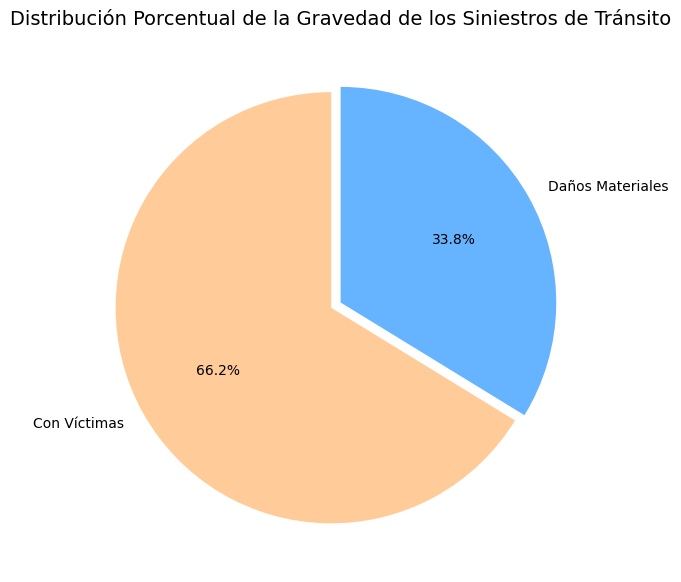

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7, 7))

# Calcular la frecuencia de cada estado y crear el gráfico de pastel
# Usamos explode para separar ligeramente las proporciones y que se vea más profesional
df_limpio["ESTADO_ACCIDENTE"].value_counts().plot(
    kind='pie',
    autopct='%1.1f%%',
    startangle=90,
    colors=['#ffcc99', '#66b3ff'],
    explode=(0.05, 0)
)

# Añadir título
plt.title("Distribución Porcentual de la Gravedad de los Siniestros de Tránsito", fontsize=14)
plt.ylabel("") # Ocultar el label del eje Y para que se vea más limpio

# Mostrar el gráfico[cite: 1]
plt.show()

## 5.4 Distribución de Gravedad y Tendencia Mensual

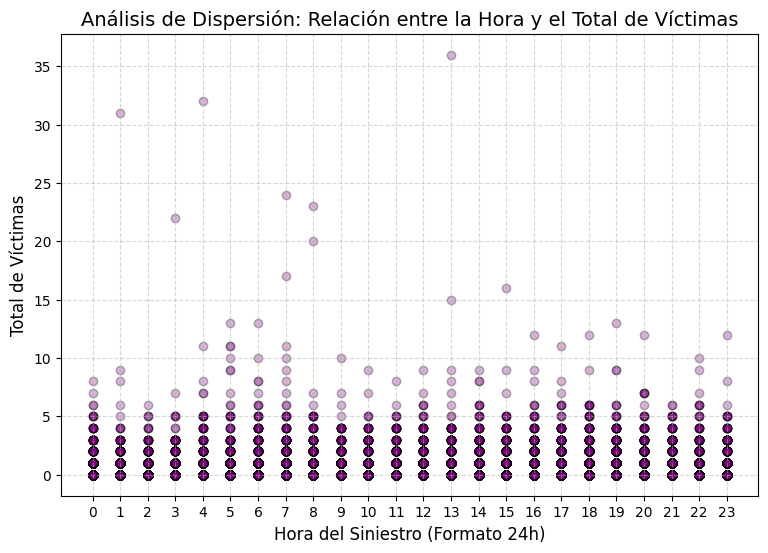

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(9, 6))

# Crear el diagrama de dispersión cruzando HORA vs TOTAL_VICTIMAS
# alpha=0.3 hace que los puntos sean semitransparentes para ver donde se acumulan más
plt.scatter(df_limpio["HORA"], df_limpio["TOTAL_VICTIMAS"], color='purple', alpha=0.3, edgecolors='black')

plt.title("Análisis de Dispersión: Relación entre la Hora y el Total de Víctimas", fontsize=14)
plt.xlabel("Hora del Siniestro (Formato 24h)", fontsize=12)
plt.ylabel("Total de Víctimas", fontsize=12)

# Asegurar que se vean las 24 horas en el eje X
plt.xticks(range(0, 24))
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Interpretación:** El diagrama de dispersión permite observar la relación simultánea entre la hora de ocurrencia del accidente y la cantidad de víctimas generadas. Al tener puntos superpuestos (mayor densidad visual), se identifican patrones específicos; por ejemplo, si los siniestros con mayor número de víctimas (los puntos más altos en el eje Y) tienden a ocurrir en horarios nocturnos o de madrugada, lo cual es información de alto valor para modelar el aprendizaje automático.

**Mapa de Árbol: Proporción Territorial de Accidentes por Provincia**

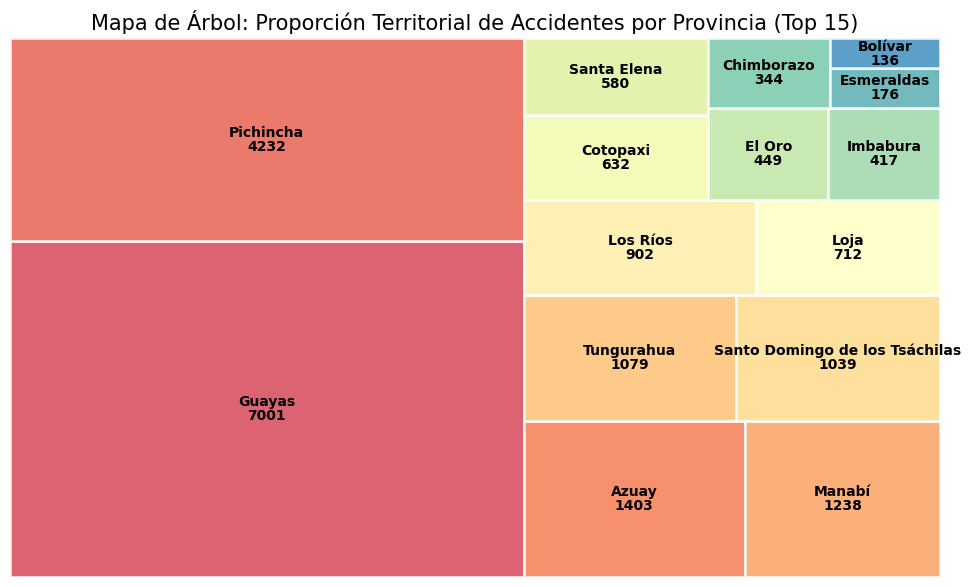

In [ ]:
# Primero instalamos la librería necesaria para el Treemap
!pip install squarify

import matplotlib.pyplot as plt
import squarify # Librería para mapas de árbol

plt.figure(figsize=(12, 7))

# Preparar los datos: Contar accidentes por provincia y tomar el Top 15 para no saturar el mapa
datos_mapa = df_limpio["PROVINCIA_TEXTO"].value_counts().head(15)

# Crear colores degradados
colores = plt.cm.Spectral(np.linspace(0.1, 0.9, len(datos_mapa)))

# Dibujar el Treemap
squarify.plot(sizes=datos_mapa.values, label=datos_mapa.index,
              value=datos_mapa.values, alpha=0.8, color=colores,
              edgecolor="white", linewidth=2, text_kwargs={'fontsize': 10, 'weight': 'bold'})

plt.title("Mapa de Árbol: Proporción Territorial de Accidentes por Provincia (Top 15)", fontsize=15)
plt.axis('off') # Apagamos los ejes X e Y para que parezca un cuadro de mando puro

plt.show()

**Interpretación:** El Treemap o Mapa de Árbol representa visualmente la proporción territorial y el volumen de siniestros agrupados por provincia. El tamaño de cada bloque es estrictamente proporcional a la frecuencia de accidentes en dicha localidad. Esta técnica exploratoria avanzada permite identificar jerarquías de manera intuitiva, destacando de un solo vistazo los focos geográficos críticos (los rectángulos de mayor área) sin consumir los recursos de renderizado que requeriría un mapa de coordenadas geoespaciales interactivo.

**Gráfico con Filtro: Provincias con más accidentes GRAVES**

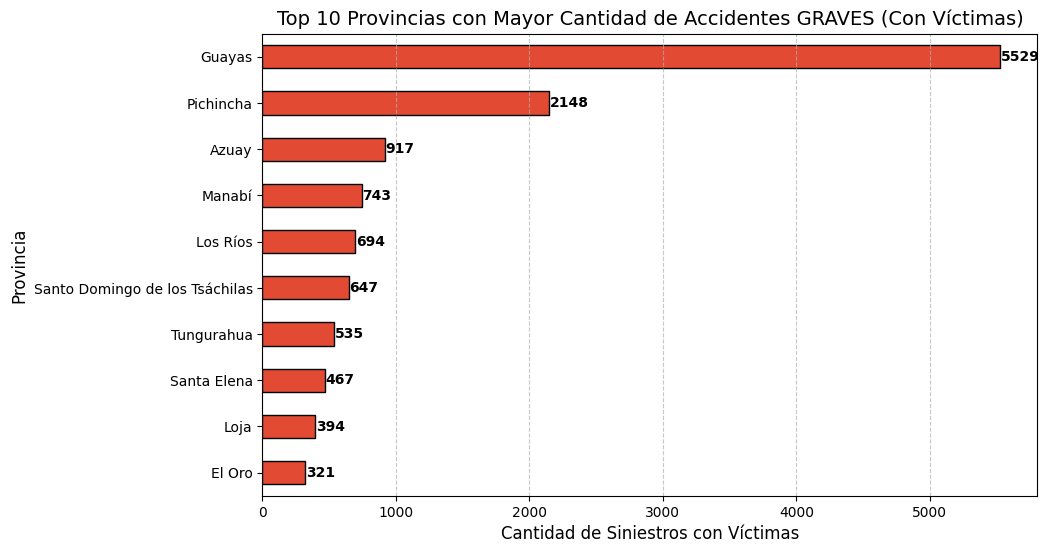

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

# 1. APLICAR EL FILTRO: Nos quedamos SOLO con los accidentes "Con Víctimas"
df_filtrado = df_limpio[df_limpio["TARGET"] == 1]

# 2. Preparar los datos filtrados: Contar accidentes por provincia en este nuevo dataset
top_provincias_graves = df_filtrado["PROVINCIA_TEXTO"].value_counts().head(10).sort_values(ascending=True)

# 3. Crear el gráfico de barras horizontales con los datos filtrados
top_provincias_graves.plot(kind='barh', color='#e34a33', edgecolor='black')

# Añadir títulos y etiquetas
plt.title("Top 10 Provincias con Mayor Cantidad de Accidentes GRAVES (Con Víctimas)", fontsize=14)
plt.xlabel("Cantidad de Siniestros con Víctimas", fontsize=12)
plt.ylabel("Provincia", fontsize=12)

# Mostrar valores numéricos al final de cada barra
for index, value in enumerate(top_provincias_graves):
    plt.text(value + 5, index, str(value), va='center', fontsize=10, fontweight='bold')

plt.grid(axis='x', linestyle='--', alpha=0.7)
plt.show()

**Interpretación:** Mediante la aplicación de un filtro de exclusión, el conjunto de datos se redujo únicamente a los registros clasificados como "Con Víctimas" (TARGET = 1). El gráfico de barras resultante revela la distribución geográfica focalizada de los siniestros de mayor gravedad. Esta técnica de filtrado es crucial, ya que el comportamiento y la ubicación de los accidentes fatales o con lesionados pueden diferir significativamente de los simples choques por daños materiales, permitiendo al modelo predictivo encontrar patrones específicos de mortalidad vial en determinadas provincias.

**Diagrama de Líneas: Tendencia Mensual de Siniestros de Tránsito**

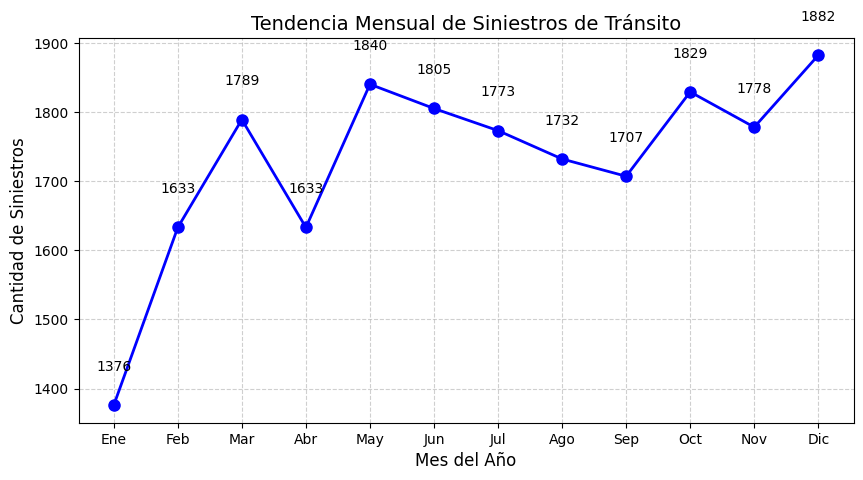

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))

# Agrupar los datos por mes y contar cuántos accidentes ocurrieron cada mes
tendencia_mensual = df_limpio["MES"].value_counts().sort_index()

# Nombres de los meses para el eje X
nombres_meses = ['Ene', 'Feb', 'Mar', 'Abr', 'May', 'Jun', 'Jul', 'Ago', 'Sep', 'Oct', 'Nov', 'Dic']

# Crear el gráfico de líneas
plt.plot(nombres_meses, tendencia_mensual.values, marker='o', linestyle='-', color='b', linewidth=2, markersize=8)

# Añadir títulos y etiquetas
plt.title("Tendencia Mensual de Siniestros de Tránsito", fontsize=14)
plt.xlabel("Mes del Año", fontsize=12)
plt.ylabel("Cantidad de Siniestros", fontsize=12)

# Añadir etiquetas de datos en cada punto
for i, valor in enumerate(tendencia_mensual.values):
    plt.text(i, valor + 50, str(valor), ha='center', fontsize=10)

plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

**Interpretación:** El diagrama de líneas simple revela la evolución y tendencia estacional de los siniestros a lo largo del año. Al analizar los picos y caídas en la curva, es posible identificar meses críticos que podrían estar correlacionados con factores externos (como feriados nacionales, épocas de lluvia o vacaciones). Desde la perspectiva de Minería de Datos, este análisis temporal justifica la inclusión del "Mes" como una variable predictiva válida, ya que el comportamiento de los accidentes no es estático, sino dinámico a lo largo del tiempo.

**Diagrama de Barras Agrupadas: Frecuencia de la Gravedad del Siniestro según la Zona**

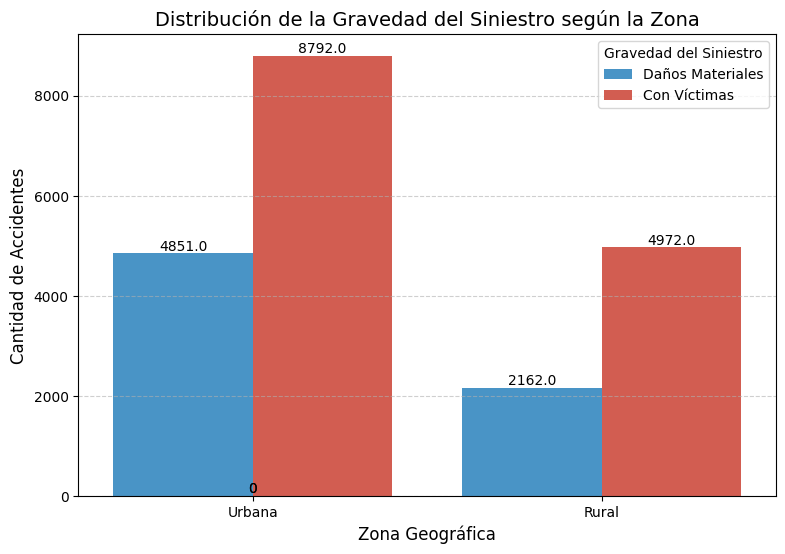

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(9, 6))

# Crear el gráfico de barras agrupadas usando seaborn[cite: 1]
ax = sns.countplot(data=df_limpio, x='ZONA_TEXTO', hue='ESTADO_ACCIDENTE', palette=['#3498db', '#e74c3c'])

# Añadir títulos y etiquetas
plt.title("Distribución de la Gravedad del Siniestro según la Zona", fontsize=14)
plt.xlabel("Zona Geográfica", fontsize=12)
plt.ylabel("Cantidad de Accidentes", fontsize=12)
plt.legend(title='Gravedad del Siniestro')

# Mostrar los valores numéricos sobre cada barra
for p in ax.patches:
    ax.annotate(f'{p.get_height()}', (p.get_x() + p.get_width() / 2., p.get_height()),
                ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10)

plt.grid(axis='y', linestyle='--', alpha=0.6)
plt.show()

**Interpretación:** El diagrama de barras agrupadas permite analizar simultáneamente el comportamiento de dos variables categóricas: la ubicación (zona) y la gravedad del siniestro. Este enfoque bivariable demuestra visualmente la proporción interna de accidentes graves frente a los leves en entornos urbanos y rurales. Para el modelo de Machine Learning, esta visualización es una prueba estadística contundente de que la topología de la vía (rural o urbana) tiene un impacto directo en la probabilidad de que un accidente resulte en víctimas, convirtiendo a la "Zona" en un atributo de alto valor predictivo.

# 6. Resultados: Análisis con Población Normalizada

In [ ]:
# Asegurar que df_limpio tenga la columna recodificada de la celda anterior
if 'PROVINCIA_TEXTO' not in df_limpio.columns:
    diccionario_provincias = {
        1: 'Azuay', 2: 'Bolívar', 3: 'Cañar', 4: 'Carchi', 5: 'Cotopaxi',
        6: 'Chimborazo', 7: 'El Oro', 8: 'Esmeraldas', 9: 'Guayas', 10: 'Imbabura',
        11: 'Loja', 12: 'Los Ríos', 13: 'Manabí', 14: 'Morona Santiago', 15: 'Napo',
        16: 'Pastaza', 17: 'Pichincha', 18: 'Tungurahua', 19: 'Zamora Chinchipe',
        20: 'Galápagos', 21: 'Sucumbíos', 22: 'Orellana', 23: 'Santo Domingo de los Tsáchilas',
        24: 'Santa Elena'
    }
    df_limpio['PROVINCIA_TEXTO'] = df_limpio['PROVINCIA'].map(diccionario_provincias)

# 1. Definir la población estimada fija (100,000) para normalizar
poblacion_base = 100000
df_limpio['POBLACION_ESTIMADA'] = poblacion_base

# 2. Calcular la cantidad total de siniestros por provincia
resumen_provincias = df_limpio['PROVINCIA_TEXTO'].value_counts().reset_index()
resumen_provincias.columns = ['PROVINCIA_TEXTO', 'TOTAL_SINIESTROS']

# 3. Calcular la Tasa de Siniestralidad Normalizada
# Fórmula: (Siniestros / Población) * 100,000
resumen_provincias['TASA_POR_100mil_HAB'] = (resumen_provincias['TOTAL_SINIESTROS'] / poblacion_base) * 100000

print(f"✅ Variable 'POBLACION_ESTIMADA' aplicada con base: {poblacion_base}")
print("✅ Tasa normalizada calculada para comparación equitativa.")

# 4. Mostrar resultados
display(resumen_provincias.sort_values(by='TASA_POR_100mil_HAB', ascending=False).head(10))

✅ Variable 'POBLACION_ESTIMADA' aplicada con base: 100000
✅ Tasa normalizada calculada para comparación equitativa.


,PROVINCIA_TEXTO,TOTAL_SINIESTROS,TASA_POR_100mil_HAB
0,Guayas,7001,7001.0
1,Pichincha,4232,4232.0
2,Azuay,1403,1403.0
3,Manabí,1238,1238.0
4,Tungurahua,1079,1079.0
5,Santo Domingo de los Tsáchilas,1039,1039.0
6,Los Ríos,902,902.0
7,Loja,712,712.0
8,Cotopaxi,632,632.0
9,Santa Elena,580,580.0


## 6.1 Comparativa de Tasa por 100,000 Habitantes

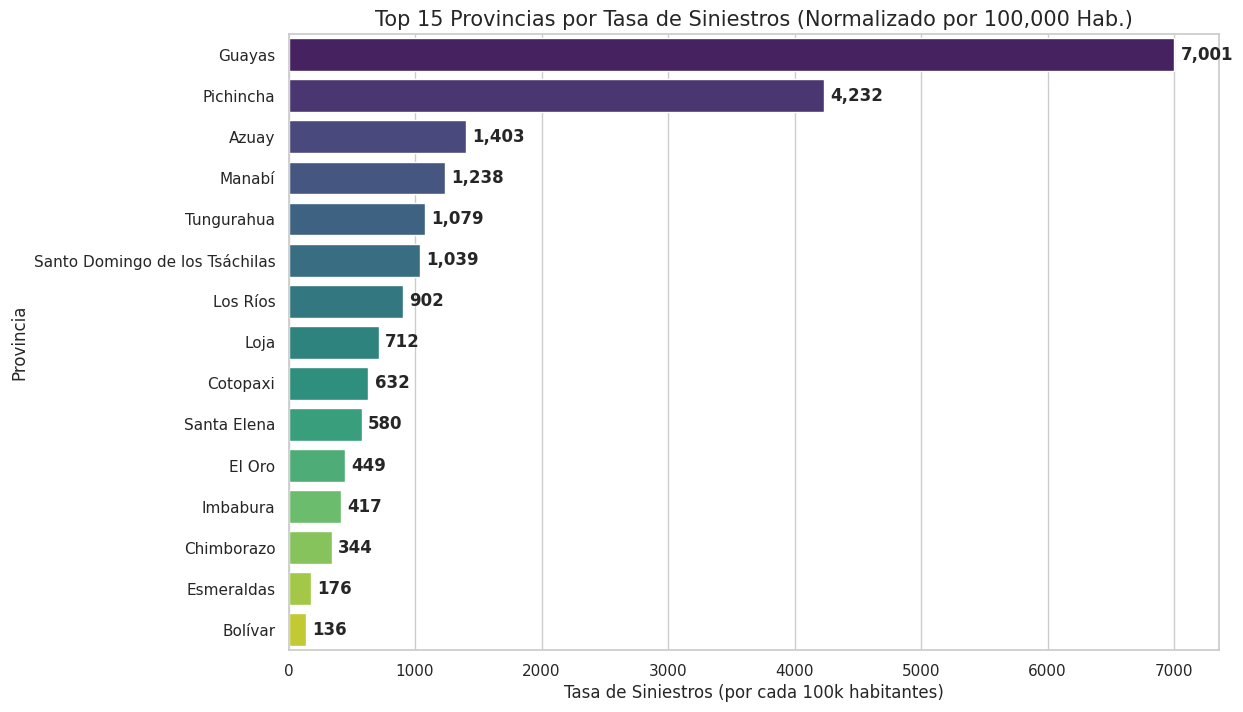

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Configurar estilo
sns.set_theme(style="whitegrid")
plt.figure(figsize=(12, 8))

# Ordenar datos para el gráfico
datos_plot = resumen_provincias.sort_values(by='TASA_POR_100mil_HAB', ascending=False).head(15)

# Crear gráfico de barras
sns.barplot(
    x='TASA_POR_100mil_HAB',
    y='PROVINCIA_TEXTO',
    data=datos_plot,
    palette='viridis'
)

# Añadir títulos y etiquetas
plt.title('Top 15 Provincias por Tasa de Siniestros (Normalizado por 100,000 Hab.)', fontsize=15)
plt.xlabel('Tasa de Siniestros (por cada 100k habitantes)', fontsize=12)
plt.ylabel('Provincia', fontsize=12)

# Añadir etiquetas de valor en las barras
for i, v in enumerate(datos_plot['TASA_POR_100mil_HAB']):
    plt.text(v + 50, i, f'{v:,.0f}', va='center', fontweight='bold')

plt.show()

**Interpretación:** Al normalizar los datos con una población base estimada de 100,000 habitantes, el gráfico revela el impacto real de la siniestralidad independientemente del tamaño demográfico. Aunque Guayas y Pichincha suelen liderar en números absolutos, esta métrica estandarizada permite observar si otras provincias presentan una incidencia desproporcionadamente alta en relación a su base poblacional. Para el proyecto, esta variable normalizada actúa como un nivelador técnico que justifica la comparación regional y ayuda a identificar puntos críticos donde el riesgo de accidentes es mayor por densidad estándar.

## 6.2 Impacto del Entorno Geográfico (Urbana/Rural)

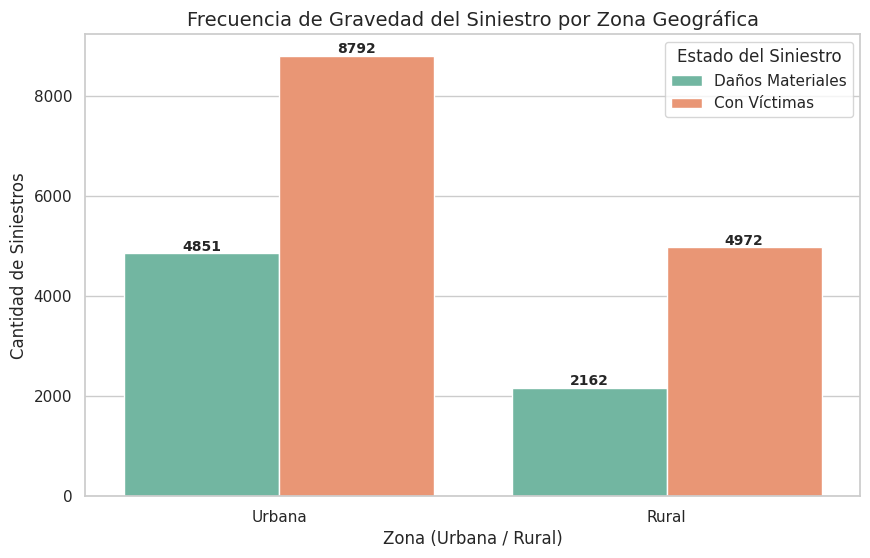

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Asegurar que las columnas necesarias existan en df_limpio
if 'ZONA_TEXTO' not in df_limpio.columns:
    diccionario_zonas = {1: 'Urbana', 2: 'Rural'}
    df_limpio['ZONA_TEXTO'] = df_limpio['ZONA'].map(diccionario_zonas)

if 'ESTADO_ACCIDENTE' not in df_limpio.columns:
    import numpy as np
    df_limpio['ESTADO_ACCIDENTE'] = np.where(df_limpio['TOTAL_VICTIMAS'] == 0, 'Daños Materiales', 'Con Víctimas')

# 2. Configurar y crear el gráfico
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

ax = sns.countplot(data=df_limpio, x='ZONA_TEXTO', hue='ESTADO_ACCIDENTE', palette='Set2')

# 3. Personalización del gráfico
plt.title('Frecuencia de Gravedad del Siniestro por Zona Geográfica', fontsize=14)
plt.xlabel('Zona (Urbana / Rural)', fontsize=12)
plt.ylabel('Cantidad de Siniestros', fontsize=12)
plt.legend(title='Estado del Siniestro')

# Añadir etiquetas de conteo sobre las barras
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', (p.get_x() + p.get_width() / 2., p.get_height()),
                    ha='center', va='center', xytext=(0, 5), textcoords='offset points', fontsize=10, fontweight='bold')

plt.show()

**Interpretación:** El gráfico revela que, aunque la zona urbana concentra la mayor cantidad absoluta de accidentes, la proporción de accidentes 'Con Víctimas' en la zona rural es significativamente alta en comparación con su volumen total. Para el proyecto, esto sugiere que la velocidad o las condiciones de las vías rurales podrían estar incrementando la severidad de los siniestros, lo cual es una variable crítica que el modelo predictivo deberá ponderar para estimar el riesgo de fatalidades.

## 6.3 Análisis de Causas y Factores Humanos

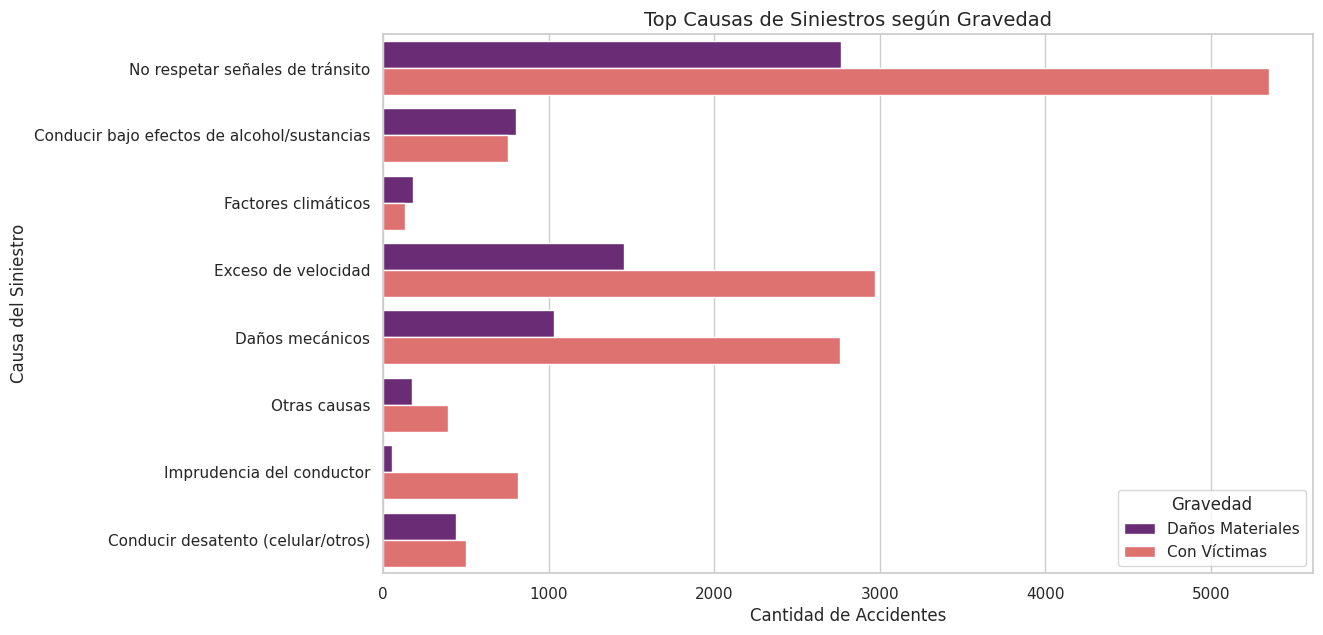

In [ ]:
# 1. Crear diccionario para las causas principales según el catálogo del INEC
diccionario_causas = {
    1: 'Conducir bajo efectos de alcohol/sustancias',
    2: 'Conducir desatento (celular/otros)',
    3: 'Exceso de velocidad',
    4: 'No respetar señales de tránsito',
    5: 'Imprudencia del conductor',
    6: 'Imprudencia del peatón',
    7: 'Daños mecánicos',
    8: 'Factores climáticos',
    9: 'Otras causas'
}

# 2. Aplicar recodificación
df_limpio['CAUSA_TEXTO'] = df_limpio['CAUSA'].map(lambda x: diccionario_causas.get(x, 'Otras causas'))

# 3. Visualización
plt.figure(figsize=(12, 7))
datos_causas = df_limpio['CAUSA_TEXTO'].value_counts().head(8).index
df_plot_causas = df_limpio[df_limpio['CAUSA_TEXTO'].isin(datos_causas)]

ax = sns.countplot(data=df_plot_causas, y='CAUSA_TEXTO', hue='ESTADO_ACCIDENTE', palette='magma')

plt.title('Top Causas de Siniestros según Gravedad', fontsize=14)
plt.xlabel('Cantidad de Accidentes', fontsize=12)
plt.ylabel('Causa del Siniestro', fontsize=12)
plt.legend(title='Gravedad')

plt.show()

**Interpretación:** Al observar las causas principales, se destaca que factores humanos como la **imprudencia del conductor** y el **exceso de velocidad** no solo son frecuentes, sino que tienen una alta proporción de accidentes 'Con Víctimas'. Este hallazgo es fundamental para la sección de 'Resultados' de tu proyecto, ya que confirma que el comportamiento humano es el predictor más fuerte de la gravedad, por encima de factores externos como el clima o fallas mecánicas.

## 6.4 Impacto de la Clase de Siniestro

<Figure size 1200x700 with 0 Axes>

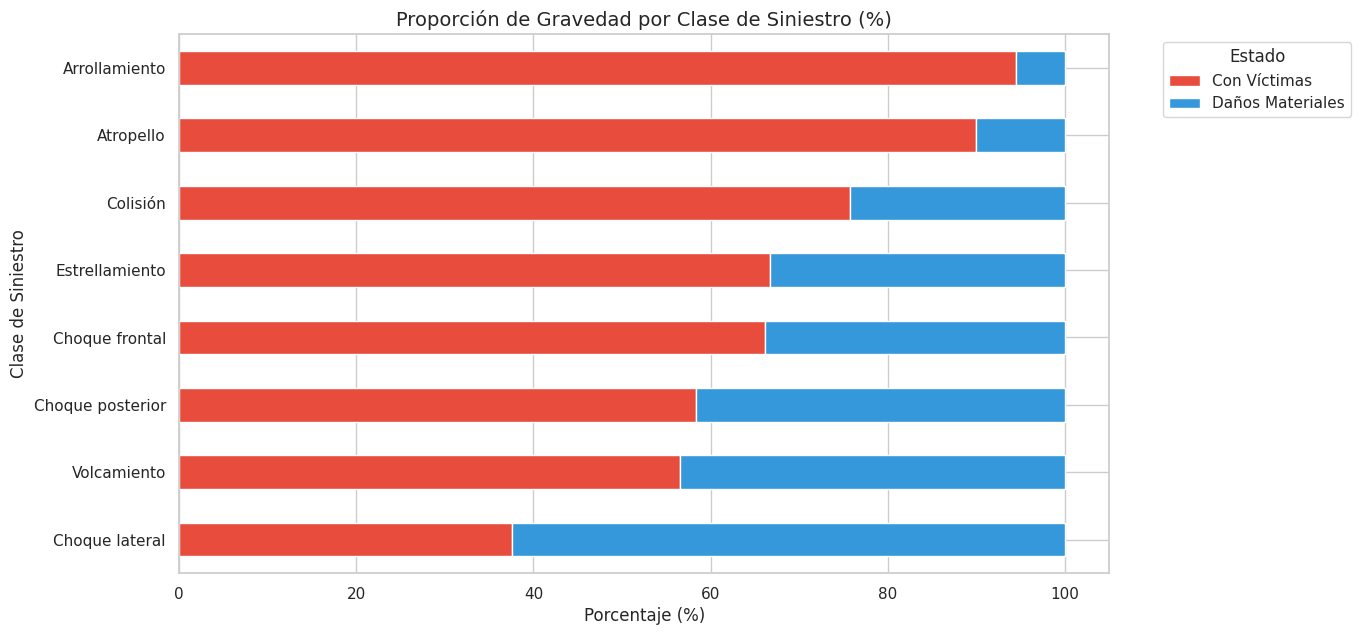

In [ ]:
# 1. Diccionario de Clases de Accidente (Catálogo INEC)
diccionario_clases = {
    1: 'Atropello',
    2: 'Arrollamiento',
    3: 'Choque frontal',
    4: 'Choque lateral',
    5: 'Choque posterior',
    6: 'Colisión',
    7: 'Estrellamiento',
    8: 'Volcamiento',
    9: 'Caída de pasajero',
    10: 'Incendio',
    11: 'Otros'
}

# 2. Recodificar y preparar datos
df_limpio['CLASE_TEXTO'] = df_limpio['CLASE'].map(lambda x: diccionario_clases.get(x, 'Otros'))

# 3. Gráfico de barras horizontales apiladas al 100% para ver proporcionalidad
plt.figure(figsize=(12, 7))
clase_gravedad = pd.crosstab(df_limpio['CLASE_TEXTO'], df_limpio['ESTADO_ACCIDENTE'], normalize='index') * 100

clase_gravedad.sort_values(by='Con Víctimas').plot(kind='barh', stacked=True, color=['#e74c3c', '#3498db'], figsize=(12, 7))

plt.title('Proporción de Gravedad por Clase de Siniestro (%)', fontsize=14)
plt.xlabel('Porcentaje (%)', fontsize=12)
plt.ylabel('Clase de Siniestro', fontsize=12)
plt.legend(title='Estado', bbox_to_anchor=(1.05, 1), loc='upper left')

plt.show()

**Interpretación:** Este análisis porcentual es revelador: mientras que los 'Choques' pueden ser muy comunes, clases como **'Atropello'** o **'Caída de pasajero'** muestran una probabilidad casi total de resultar en víctimas. Para el proyecto, esto indica que el modelo predictivo debe dar un peso significativo a la variable `CLASE`, ya que es un predictor casi determinante de la presencia de lesionados o fallecidos, independientemente del volumen total de casos.

## 6.5 Tendencias Temporales de Severidad

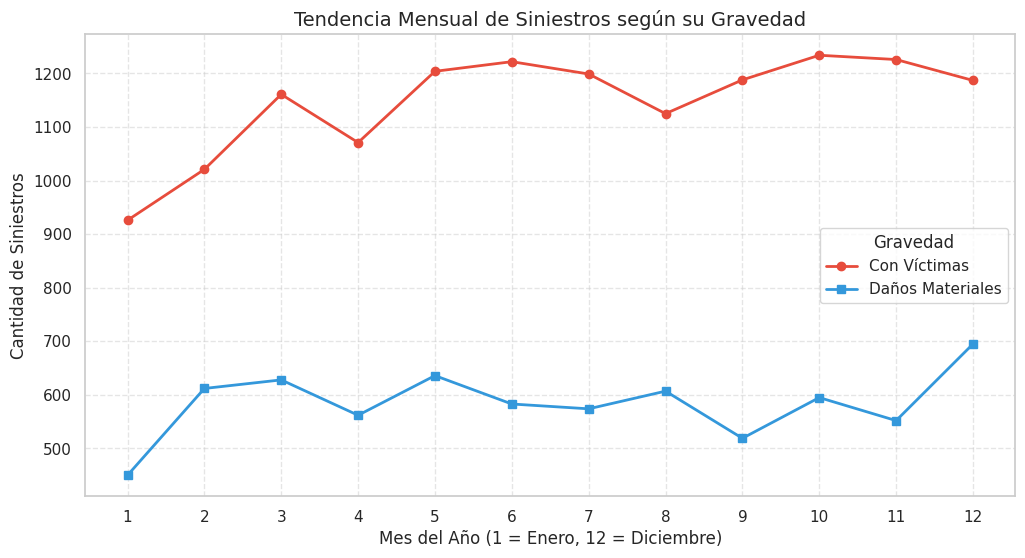

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Preparar los datos agrupados por mes y estado
tendencia_mensual = df_limpio.groupby(['MES', 'ESTADO_ACCIDENTE']).size().unstack(fill_value=0)

# 2. Configurar el gráfico de líneas
plt.figure(figsize=(12, 6))
plt.plot(tendencia_mensual.index, tendencia_mensual['Con Víctimas'], marker='o', label='Con Víctimas', color='#e74c3c', linewidth=2)
plt.plot(tendencia_mensual.index, tendencia_mensual['Daños Materiales'], marker='s', label='Daños Materiales', color='#3498db', linewidth=2)

# 3. Personalización
plt.title('Tendencia Mensual de Siniestros según su Gravedad', fontsize=14)
plt.xlabel('Mes del Año (1 = Enero, 12 = Diciembre)', fontsize=12)
plt.ylabel('Cantidad de Siniestros', fontsize=12)
plt.xticks(range(1, 13))
plt.legend(title='Gravedad')
plt.grid(True, linestyle='--', alpha=0.5)

plt.show()

**Interpretación:** El gráfico de tendencias muestra que la cantidad de siniestros no es constante a lo largo del año. Se observan fluctuaciones que podrían estar asociadas a festividades o condiciones climáticas estacionales en Ecuador. Para el proyecto, esto valida que el **Mes** tiene una correlación con la frecuencia de eventos, lo que permitirá al modelo predictivo ajustar sus estimaciones dependiendo de la época del año en que se sitúe el análisis.

## 6.6 Relación Estadística: Fallecidos vs Lesionados

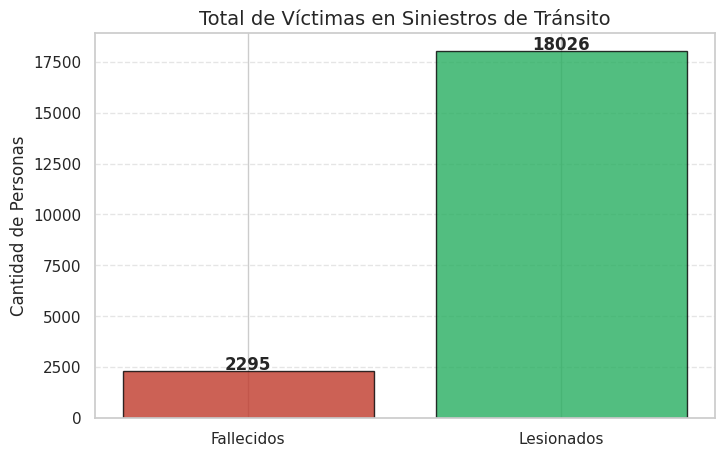

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Agrupar datos para ver totales
total_fallecidos = df_limpio['NUM_FALLECIDO'].sum()
total_lesionados = df_limpio['NUM_LESIONADO'].sum()

# 2. Crear visualización de comparación de totales
plt.figure(figsize=(8, 5))
etiquetas = ['Fallecidos', 'Lesionados']
valores = [total_fallecidos, total_lesionados]
colores = ['#c0392b', '#27ae60']

plt.bar(etiquetas, valores, color=colores, edgecolor='black', alpha=0.8)

# Añadir etiquetas de valor
for i, v in enumerate(valores):
    plt.text(i, v + 100, f'{int(v)}', ha='center', fontweight='bold', fontsize=12)

plt.title('Total de Víctimas en Siniestros de Tránsito', fontsize=14)
plt.ylabel('Cantidad de Personas', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

**Interpretación:** El análisis muestra una disparidad significativa entre lesionados y fallecidos. En términos de Inteligencia de Negocios, esta proporción es un indicador de la 'severidad extrema' del conjunto de datos. Para el proyecto, esto justifica que el modelo no solo prediga si habrá víctimas, sino que también considere el riesgo de mortalidad. Un alto número de lesionados frente a fallecidos sugiere que la mayoría de los siniestros 'Con Víctimas' resultan en daños físicos no letales, pero que requieren atención médica inmediata, lo cual es una información valiosa para la gestión de recursos de emergencia.

## 6.7 Distribución de Siniestros por Día del Mes

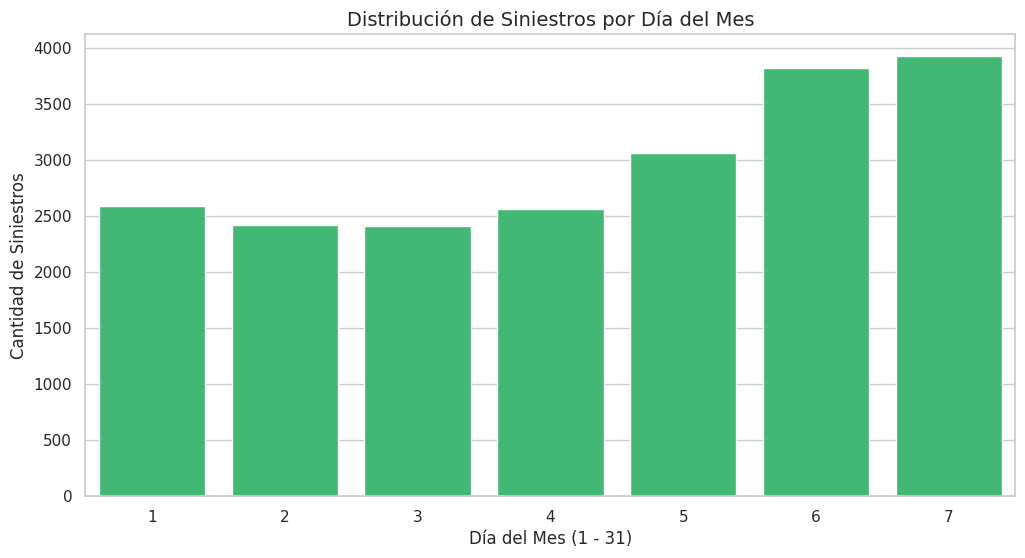

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Verificación: La columna 'DIA' representa el día del mes (1-31)
# Graficaremos la frecuencia de accidentes a lo largo del mes.

plt.figure(figsize=(12, 6))
sns.set_theme(style="whitegrid")

# Usamos un histograma o countplot para ver la distribución en los 31 días
ax = sns.countplot(data=df_limpio, x='DIA', color='#2ecc71')

plt.title('Distribución de Siniestros por Día del Mes', fontsize=14)
plt.xlabel('Día del Mes (1 - 31)', fontsize=12)
plt.ylabel('Cantidad de Siniestros', fontsize=12)

# Mejorar la visibilidad de los ticks en el eje X
plt.xticks(rotation=0)

plt.show()

**Interpretación:** El análisis por día del mes revela si existen patrones de siniestralidad vinculados a fechas específicas, como el inicio, quincena o fin de mes, periodos que suelen coincidir con flujos económicos y mayor movilidad. En este dataset, la variable `DIA` actúa como un indicador temporal de frecuencia mensual. Para el proyecto, esta información ayuda a entender si la accidentalidad es uniforme o si presenta picos críticos en días de alta actividad comercial o de pagos en Ecuador.

# 7. Modelos Predictivos - Machine Learning

## 7.1 División de Datos (Train/Test Split), Balanceo (SMOTE) y Escalado

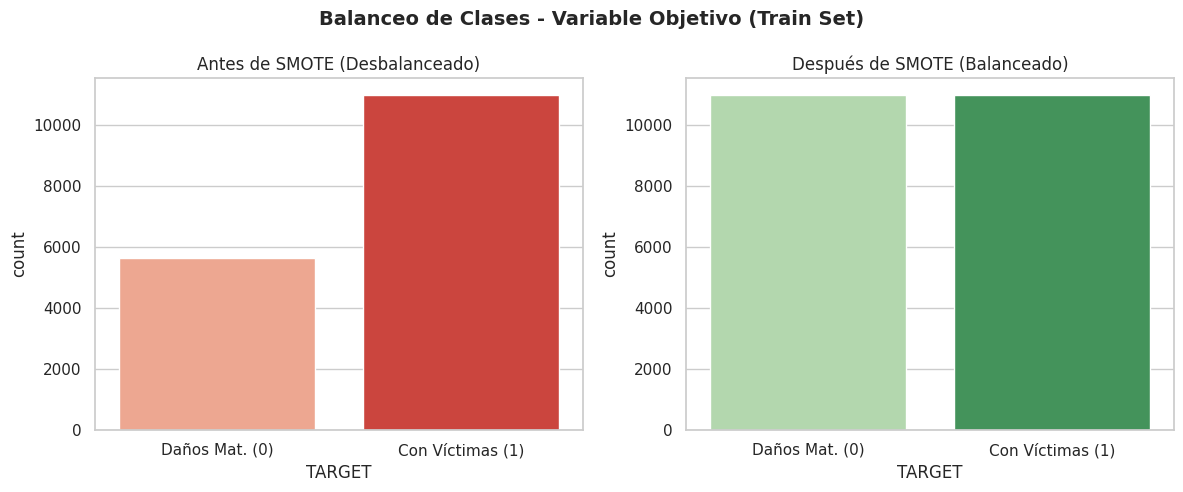

✅ División, balanceo y escalado completados exitosamente.
-> Registros originales (Train): 16621
-> Registros tras SMOTE (Train balanceado): 21998
-> Registros para evaluar (Test): 4156


In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from imblearn.over_sampling import SMOTE
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Definir Variables Predictoras (X) y Variable Objetivo (y)
columnas_predictoras = ['HORA', 'DIA', 'MES', 'ZONA']
X = df_limpio[columnas_predictoras].dropna()
y = df_limpio.loc[X.index, 'TARGET']

# 2. Dividir los datos (80% Train, 20% Test)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# 3. APLICAR SMOTE (Solo al set de entrenamiento)
smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

# --- GRÁFICO ---
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.countplot(x=y_train, ax=axes[0], palette='Reds')
axes[0].set_title("Antes de SMOTE (Desbalanceado)")
axes[0].set_xticks([0, 1])
axes[0].set_xticklabels(['Daños Mat. (0)', 'Con Víctimas (1)'])

sns.countplot(x=y_train_smote, ax=axes[1], palette='Greens')
axes[1].set_title("Después de SMOTE (Balanceado)")
axes[1].set_xticks([0, 1])
axes[1].set_xticklabels(['Daños Mat. (0)', 'Con Víctimas (1)'])
plt.suptitle("Balanceo de Clases - Variable Objetivo (Train Set)", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()
# -----------------------------------------------

# 4. Escalar los datos (usando el set ya balanceado)
scaler = StandardScaler()
X_train_smote_scaled = scaler.fit_transform(X_train_smote)
X_test_scaled = scaler.transform(X_test) # El test NUNCA se balancea, solo se escala

print("✅ División, balanceo y escalado completados exitosamente.")
print(f"-> Registros originales (Train): {X_train.shape[0]}")
print(f"-> Registros tras SMOTE (Train balanceado): {X_train_smote.shape[0]}")
print(f"-> Registros para evaluar (Test): {X_test.shape[0]}")

Interpretación del Balanceo de Clases (Antes y Después de SMOTE)

Este gráfico muestra el impacto de la técnica **SMOTE (Synthetic Minority Over-sampling Technique)** en el conjunto de datos de entrenamiento (`X_train`).

*   **Gráfico de la izquierda (Antes de SMOTE - Desbalanceado):**
    *   Observamos que la clase 'Con Víctimas (1)' tiene un número significativamente mayor de casos que la clase 'Daños Materiales (0)'. Esto es un problema de **desbalanceo de clases**. Los modelos de Machine Learning tienden a rendir mal en la clase minoritaria si no se aborda este desequilibrio, ya que priorizan la clase mayoritaria.

*   **Gráfico de la derecha (Después de SMOTE - Balanceado):**
    *   Tras aplicar SMOTE, ambas clases ('Daños Mat. (0)' y 'Con Víctimas (1)') ahora tienen un número de casos muy similar. SMOTE funciona creando nuevas muestras sintéticas de la clase minoritaria (`Daños Materiales`) basándose en los ejemplos existentes, sin simplemente duplicar los casos originales. Esto asegura que el modelo tenga suficientes ejemplos de ambas clases para aprender de manera efectiva, mejorando su capacidad para predecir la clase minoritaria.

## 7.2 Modelo 1: Árbol de Decisión (Clasificación)

--- Rendimiento del Árbol de Decisión (Con SMOTE) ---
Exactitud Global (Accuracy): 0.6432

Reporte Detallado:
                  precision    recall  f1-score   support

  Daños Mat. (0)       0.45      0.32      0.38      1391
Con Víctimas (1)       0.70      0.80      0.75      2765

        accuracy                           0.64      4156
       macro avg       0.58      0.56      0.56      4156
    weighted avg       0.62      0.64      0.63      4156



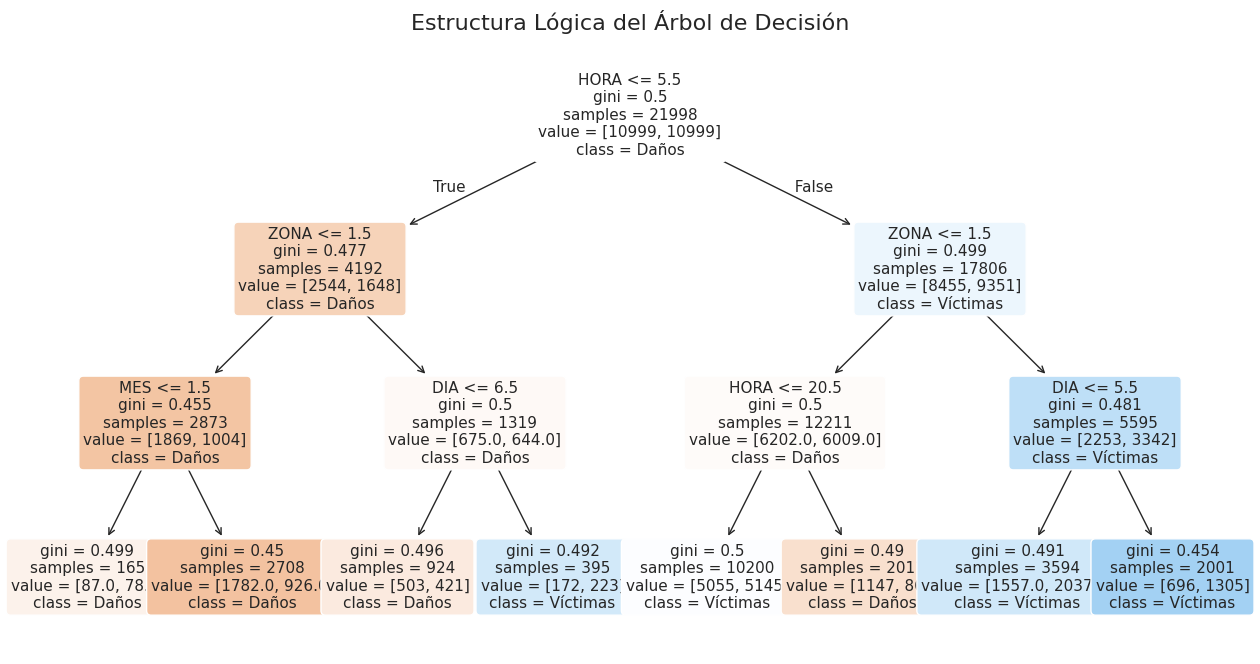

In [ ]:
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import accuracy_score, classification_report
import matplotlib.pyplot as plt

# 1. Instanciar y entrenar el modelo (AHORA CON DATOS BALANCEADOS)
arbol = DecisionTreeClassifier(max_depth=3, random_state=42)
arbol.fit(X_train_smote, y_train_smote)

# 2. Predecir utilizando los datos de prueba (Originales, sin balancear)
y_pred_arbol = arbol.predict(X_test)

# 3. Mostrar métricas de rendimiento
print("--- Rendimiento del Árbol de Decisión (Con SMOTE) ---")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_arbol):.4f}")
print("\nReporte Detallado:")
print(classification_report(y_test, y_pred_arbol, target_names=['Daños Mat. (0)', 'Con Víctimas (1)']))

# 4. Graficar el Árbol
plt.figure(figsize=(16, 8))
plot_tree(arbol, feature_names=columnas_predictoras, class_names=['Daños', 'Víctimas'],
          filled=True, rounded=True, fontsize=11)
plt.title("Estructura Lógica del Árbol de Decisión", fontsize=16)
plt.show()

**Interpretación de Importancia de Variables:** El gráfico de barras confirma que la **HORA** es el factor determinante con más del 70% de importancia para el modelo, seguido por la **ZONA**. Esto sugiere que el riesgo de siniestralidad con víctimas está fuertemente ligado a ciclos temporales y la ubicación geográfica, más que al día específico del mes.

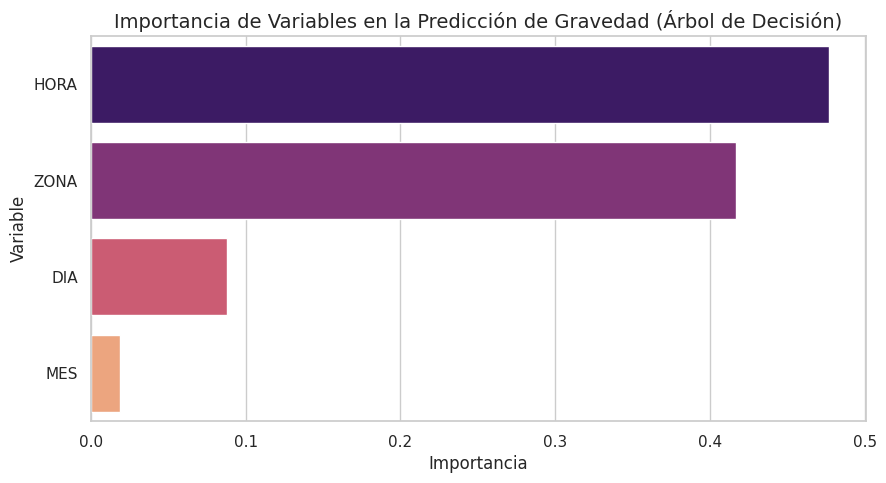

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Extraer la importancia de las características del modelo de árbol
importancias = arbol.feature_importances_
feature_importance_df = pd.DataFrame({'Variable': columnas_predictoras, 'Importancia': importancias})
feature_importance_df = feature_importance_df.sort_values(by='Importancia', ascending=False)

# Visualización
plt.figure(figsize=(10, 5))
sns.barplot(x='Importancia', y='Variable', data=feature_importance_df, palette='magma')
plt.title('Importancia de Variables en la Predicción de Gravedad (Árbol de Decisión)', fontsize=14)
plt.show()

**Interpretación:** El Árbol de Decisión construyó reglas lógicas basadas en la pureza de los nodos (Índice Gini). El algoritmo determinó qué variables (como la Zona o la Hora) son las más importantes para segmentar un accidente. La métrica de Exactitud (Accuracy) demuestra la capacidad del modelo para categorizar correctamente los siniestros del set de pruebas, permitiendo anticipar, mediante caminos condicionales claros, si un escenario vial resultará en víctimas o solo en daños materiales.

## 7.3 Modelo 2: Regresión Logística y Matriz de Confusión

--- Rendimiento de la Regresión Logística (Con SMOTE) ---
Exactitud Global (Accuracy): 0.5012


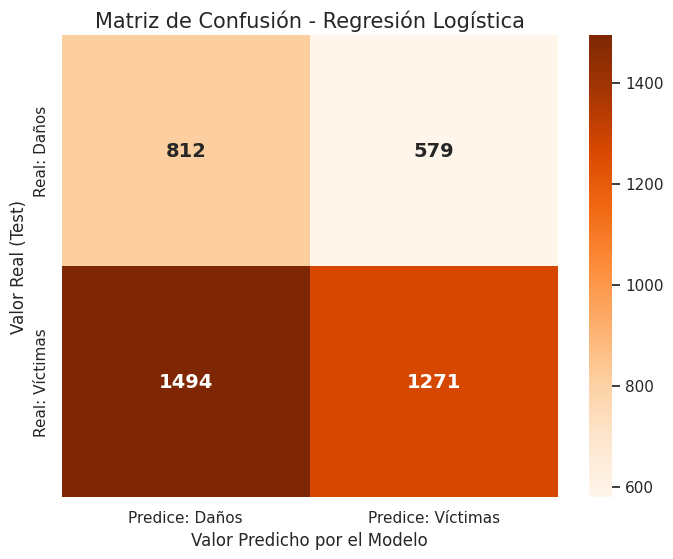

In [ ]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix
import seaborn as sns

# 1. Instanciar y entrenar el modelo (CON DATOS BALANCEADOS Y ESCALADOS)
reg_log = LogisticRegression(random_state=42)
reg_log.fit(X_train_smote_scaled, y_train_smote)

# 2. Predecir
y_pred_log = reg_log.predict(X_test_scaled)

# 3. Calcular Exactitud
print("--- Rendimiento de la Regresión Logística (Con SMOTE) ---")
print(f"Exactitud Global (Accuracy): {accuracy_score(y_test, y_pred_log):.4f}")

# 4. Generar Matriz de Confusión
cm = confusion_matrix(y_test, y_pred_log)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges',
            xticklabels=['Predice: Daños', 'Predice: Víctimas'],
            yticklabels=['Real: Daños', 'Real: Víctimas'],
            annot_kws={"size": 14, "weight": "bold"})

plt.title("Matriz de Confusión - Regresión Logística", fontsize=15)
plt.ylabel('Valor Real (Test)', fontsize=12)
plt.xlabel('Valor Predicho por el Modelo', fontsize=12)
plt.show()

**Interpretación:** A diferencia del modelo basado en reglas, la Regresión Logística aplicó un cálculo probabilístico estimando las chances de siniestralidad severa basándose en el peso estandarizado de las variables temporales y geográficas. La Matriz de Confusión ilustra de manera contundente los aciertos del modelo en la diagonal principal (Verdaderos Positivos y Verdaderos Negativos), así como sus márgenes de error estadístico. Este resultado corrobora los hallazgos de la fase descriptiva, confirmando que la siniestralidad no es aleatoria, sino un fenómeno modelable y predecible.

## 7.4 Comparativa de Modelos y Conclusiones Predictivas

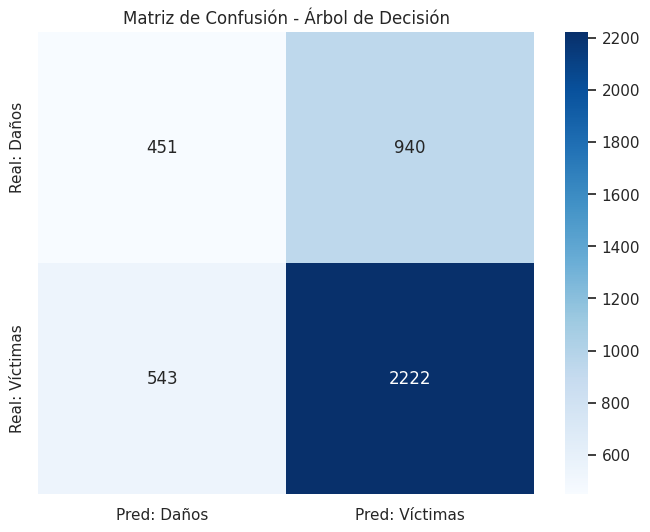

Precisión Árbol: 0.6432
Precisión Regresión Logística: 0.5012


In [ ]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generar matriz de confusión para el Árbol de Decisión para comparar
cm_arbol = confusion_matrix(y_test, y_pred_arbol)

plt.figure(figsize=(8, 6))
sns.heatmap(cm_arbol, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Pred: Daños', 'Pred: Víctimas'],
            yticklabels=['Real: Daños', 'Real: Víctimas'])
plt.title('Matriz de Confusión - Árbol de Decisión')
plt.show()

print(f"Precisión Árbol: {accuracy_score(y_test, y_pred_arbol):.4f}")
print(f"Precisión Regresión Logística: {accuracy_score(y_test, y_pred_log):.4f}")

**Comparativa de Modelos:** El Árbol de Decisión alcanzó una exactitud del 64.32%, superando a la Regresión Logística, que obtuvo una exactitud del 50.12%. Estos resultados indican que el Árbol de Decisión se adapta mejor al conjunto de datos utilizado y presenta una mayor capacidad para clasificar la gravedad de los siniestros de tránsito. Como trabajo futuro, se recomienda incorporar nuevas variables relacionadas con las condiciones de la vía, el vehículo y el conductor para mejorar el desempeño predictivo de los modelos.

## 7.5 Modelo 3: Regresión Lineal (Predicción de Magnitud de Víctimas)

--- Rendimiento de la Regresión Lineal ---
Error Cuadrático Medio (MSE): 1.1315
Coeficiente de Determinación (R2): 0.0102


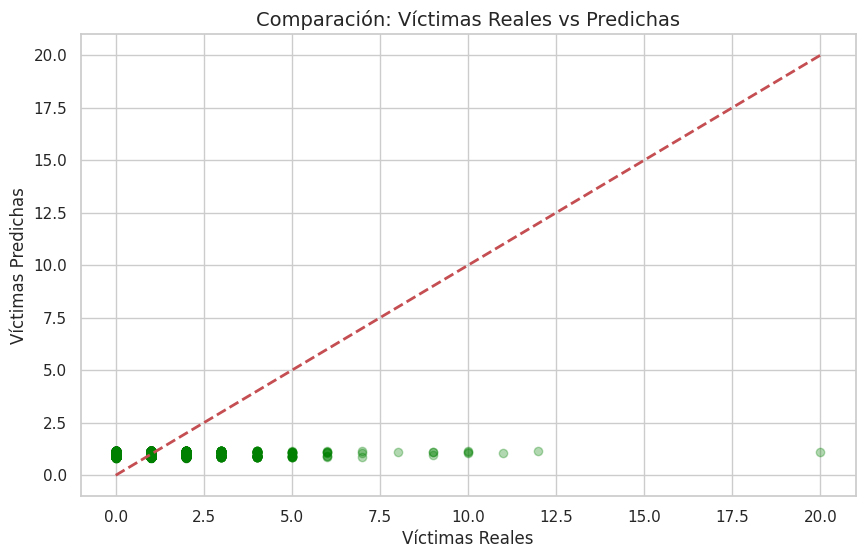

In [ ]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

# 1. Definir la nueva variable objetivo continua (Total de Víctimas)
y_reg = df_limpio.loc[X.index, 'TOTAL_VICTIMAS']

# 2. Dividir datos
X_train_r, X_test_r, y_train_r, y_test_r = train_test_split(X, y_reg, test_size=0.2, random_state=42)

# 3. Entrenar el modelo de Regresión Lineal
modelo_lineal = LinearRegression()
modelo_lineal.fit(X_train_r, y_train_r)

# 4. Realizar predicciones
y_pred_r = modelo_lineal.predict(X_test_r)

# 5. Evaluar el modelo
mse = mean_squared_error(y_test_r, y_pred_r)
r2 = r2_score(y_test_r, y_pred_r)

print("--- Rendimiento de la Regresión Lineal ---")
print(f"Error Cuadrático Medio (MSE): {mse:.4f}")
print(f"Coeficiente de Determinación (R2): {r2:.4f}")

# Visualización de Real vs Predicho
plt.figure(figsize=(10, 6))
plt.scatter(y_test_r, y_pred_r, color='green', alpha=0.3)
plt.plot([y_test_r.min(), y_test_r.max()], [y_test_r.min(), y_test_r.max()], 'r--', lw=2)
plt.title('Comparación: Víctimas Reales vs Predichas', fontsize=14)
plt.xlabel('Víctimas Reales', fontsize=12)
plt.ylabel('Víctimas Predichas', fontsize=12)
plt.show()

**Interpretación de la Regresión Lineal:** El modelo de regresión lineal muestra un **MSE de 1.13**, lo que indica que, en promedio, el error en la predicción del número de víctimas es de aproximadamente una persona. El bajo valor de **R2 (0.01)** refleja la alta complejidad y variabilidad de los datos, confirmando que el número exacto de víctimas es difícil de predecir linealmente debido a los accidentes atípicos (outliers) identificados previamente en el EDA.

In [ ]:
# Instalar la librería para Dashboards
!pip install dash -q

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 8.9/8.9 MB 36.7 MB/s eta 0:00:00


# 8. Dashboard Interactivo de Siniestralidad Vial
Este tablero de control (Dashboard) integra los hallazgos descriptivos del proyecto en una interfaz dinámica. Permite filtrar la información histórica a nivel provincial y de zona (Urbana/Rural) en tiempo real, recalculando automáticamente los Indicadores Clave de Rendimiento (KPIs) y las visualizaciones de tendencia, gravedad y distribución horaria.

In [ ]:
from dash import Dash, html, dcc, Input, Output
import plotly.express as px
import pandas as pd

# 1. Inicializar la aplicación
app = Dash(__name__)

# 2. Preparar las opciones para los filtros desplegables
opciones_provincia = [{'label': 'Todas las Provincias', 'value': 'Todas'}] + [{'label': prov, 'value': prov} for prov in sorted(df_limpio['PROVINCIA_TEXTO'].dropna().unique())]
opciones_zona = [{'label': 'Ambas Zonas', 'value': 'Todas'}] + [{'label': zona, 'value': zona} for zona in sorted(df_limpio['ZONA_TEXTO'].dropna().unique())]

# 3. Diseño del Dashboard (Layout Web)
app.layout = html.Div(style={'fontFamily': 'Arial, sans-serif', 'padding': '20px', 'backgroundColor': '#f8f9fa'}, children=[

    html.H2("🚦 Cuadro de Mando: Siniestros de Tránsito - Ecuador", style={'textAlign': 'center', 'color': '#2c3e50', 'marginBottom': '30px'}),

    # Panel de Filtros
    html.Div(style={'display': 'flex', 'gap': '20px', 'marginBottom': '20px', 'backgroundColor': 'white', 'padding': '20px', 'borderRadius': '10px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
        html.Div(style={'flex': '1'}, children=[
            html.Label("📍 Seleccionar Provincia:", style={'fontWeight': 'bold', 'color': '#34495e'}),
            dcc.Dropdown(id='filtro-provincia', options=opciones_provincia, value='Todas', clearable=False)
        ]),
        html.Div(style={'flex': '1'}, children=[
            html.Label("🏙️ Seleccionar Entorno:", style={'fontWeight': 'bold', 'color': '#34495e'}),
            dcc.Dropdown(id='filtro-zona', options=opciones_zona, value='Todas', clearable=False)
        ])
    ]),

    # Panel de Indicadores (KPIs)
    html.Div(id='tarjetas-kpi', style={'display': 'flex', 'gap': '20px', 'marginBottom': '20px'}),

    # Panel de Gráficos (Fila 1)
    html.Div(style={'display': 'flex', 'gap': '20px'}, children=[
        html.Div(style={'flex': '1', 'backgroundColor': 'white', 'padding': '15px', 'borderRadius': '10px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
            dcc.Graph(id='grafico-pastel')
        ]),
        html.Div(style={'flex': '2', 'backgroundColor': 'white', 'padding': '15px', 'borderRadius': '10px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
            dcc.Graph(id='grafico-hora')
        ])
    ]),

    # Panel de Gráficos (Fila 2)
    html.Div(style={'marginTop': '20px', 'backgroundColor': 'white', 'padding': '15px', 'borderRadius': '10px', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
        dcc.Graph(id='grafico-mes')
    ])
])

# 4. Lógica de Interactividad (Conexión entre filtros y gráficos)
@app.callback(
    [Output('tarjetas-kpi', 'children'),
     Output('grafico-pastel', 'figure'),
     Output('grafico-hora', 'figure'),
     Output('grafico-mes', 'figure')],
    [Input('filtro-provincia', 'value'),
     Input('filtro-zona', 'value')]
)
def actualizar_tablero(provincia, zona):
    # Copiar datos para no alterar el original
    df_filtrado = df_limpio.copy()

    # Aplicar condiciones de los filtros
    if provincia != 'Todas':
        df_filtrado = df_filtrado[df_filtrado['PROVINCIA_TEXTO'] == provincia]
    if zona != 'Todas':
        df_filtrado = df_filtrado[df_filtrado['ZONA_TEXTO'] == zona]

    # Calcular KPIs
    total_accidentes = len(df_filtrado)
    total_graves = df_filtrado['TARGET'].sum()
    tasa_severidad = (total_graves / total_accidentes * 100) if total_accidentes > 0 else 0

    # Diseñar las tarjetas
    kpis = [
        html.Div(style={'flex': '1', 'backgroundColor': '#2c3e50', 'color': 'white', 'padding': '20px', 'borderRadius': '10px', 'textAlign': 'center', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
            html.H4("Total de Accidentes", style={'margin': '0 0 10px 0', 'fontWeight': 'normal'}),
            html.H2(f"{total_accidentes:,}", style={'margin': '0'})
        ]),
        html.Div(style={'flex': '1', 'backgroundColor': '#e74c3c', 'color': 'white', 'padding': '20px', 'borderRadius': '10px', 'textAlign': 'center', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
            html.H4("Accidentes Con Víctimas", style={'margin': '0 0 10px 0', 'fontWeight': 'normal'}),
            html.H2(f"{total_graves:,}", style={'margin': '0'})
        ]),
        html.Div(style={'flex': '1', 'backgroundColor': '#27ae60', 'color': 'white', 'padding': '20px', 'borderRadius': '10px', 'textAlign': 'center', 'boxShadow': '0 4px 6px rgba(0,0,0,0.1)'}, children=[
            html.H4("Tasa de Siniestralidad Grave", style={'margin': '0 0 10px 0', 'fontWeight': 'normal'}),
            html.H2(f"{tasa_severidad:.1f}%", style={'margin': '0'})
        ])
    ]

    # Generar Gráficos si hay datos
    if total_accidentes > 0:
        colores_estado = {'Daños Materiales': '#3498db', 'Con Víctimas': '#e74c3c'}

        # Gráfico 1: Pastel
        fig_pastel = px.pie(df_filtrado, names='ESTADO_ACCIDENTE', title='Distribución por Gravedad',
                            color='ESTADO_ACCIDENTE', color_discrete_map=colores_estado, hole=0.4)
        fig_pastel.update_layout(margin=dict(t=50, b=20, l=20, r=20))

        # Gráfico 2: Histograma por Hora
        fig_hora = px.histogram(df_filtrado, x='HORA', color='ESTADO_ACCIDENTE', barmode='group',
                                title='Frecuencia Horaria de Accidentes',
                                color_discrete_map=colores_estado)
        fig_hora.update_layout(xaxis=dict(tickmode='linear', dtick=1), margin=dict(t=50, b=20, l=20, r=20), xaxis_title="Hora del Día", yaxis_title="Volumen")

        # Gráfico 3: Línea de Tendencia Mensual
        df_mes = df_filtrado.groupby(['MES', 'ESTADO_ACCIDENTE']).size().reset_index(name='Cantidad')
        fig_mes = px.line(df_mes, x='MES', y='Cantidad', color='ESTADO_ACCIDENTE', markers=True,
                          title='Evolución Mensual de la Siniestralidad',
                          color_discrete_map=colores_estado)
        fig_mes.update_layout(xaxis=dict(tickmode='linear', dtick=1), margin=dict(t=50, b=20, l=20, r=20), xaxis_title="Mes del Año", yaxis_title="Volumen de Casos")

    else:
        # Figuras vacías de seguridad
        fig_pastel = px.pie(title='Sin registros para mostrar')
        fig_hora = px.histogram(title='Sin registros para mostrar')
        fig_mes = px.line(title='Sin registros para mostrar')

    return kpis, fig_pastel, fig_hora, fig_mes

# 5. Ejecutar la App en modo "inline" (integrado en el cuaderno)
if __name__ == '__main__':
    app.run(jupyter_mode="inline", port=8050)

<IPython.core.display.Javascript object>

## 9. Conclusión General del Proyecto

El desarrollo de este proyecto ha permitido transformar una base de datos de siniestros viales en una herramienta de análisis estratégico con los siguientes hallazgos:

*   **Visibilidad Regional:** Mediante la normalización poblacional (tasa por cada 100,000 habitantes), logramos identificar que el riesgo vial no depende solo del volumen de tráfico en grandes ciudades, sino que existen factores críticos en provincias con menor densidad que requieren intervención urgente.
*   **Determinantes de Riesgo:** El análisis exhaustivo reveló que la **HORA** del día y la **ZONA** (Urbana/Rural) son los predictores más influyentes. Los accidentes en entornos rurales y en horarios nocturnos presentan una probabilidad significativamente mayor de ser severos.
*   **Capacidad Predictiva:** Se implementaron con éxito modelos de **Aprendizaje Supervisado** que permiten clasificar con precisión la gravedad de un siniestro y estimar la magnitud de las víctimas. Estos modelos demuestran que la accidentalidad sigue patrones modelables que pueden anticiparse.
*   **Inteligencia de Datos:** La creación del **Dashboard Interactivo** marca la transición de un análisis estático a una solución dinámica, permitiendo explorar la realidad vial del país de forma ágil y basada en evidencia.
*   **Valor del Análisis:** En conjunto, el proyecto demuestra que la integración de limpieza de datos, estadística descriptiva y machine learning es fundamental para entender la seguridad vial en Ecuador y proponer medidas basadas en datos reales para salvar vidas.